# Sales Prediction

### Import Dependencies

In [1]:
# Core data handling
import shutil
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting + preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# The three models
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

# Pipeline + metric + ensemble-weight solver
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
from scipy.optimize import nnls

# **Exploratory Data Analysis (EDA)**

In [2]:
# Load the raw training data as provided by the competition
df = pd.read_csv("../data/train.csv")
df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [3]:
# Quick sanity check on the size of the dataset (rows, columns)
df.shape

(6818, 13)

In [4]:
# Column dtypes and non-null counts -- first look at where the missing data lives
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 692.6 KB


In [5]:
# find the number of missing values in each column
df.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919


`product_weight_kg` and `store_size` both have real gaps -- handled in the wrangle function below.

In [6]:
# good, wrap all the cleaning into a wrangle function so it can be applied
# identically to both train.csv and test.csv (no train/test skew in preprocessing)
def wrangle(filepath):
    df = pd.read_csv(filepath)

    # standardize category casing (e.g. "SNACK FOODS" / "snack foods" -> "Snack Foods")
    df["product_category"] = df["product_category"].str.strip().str.title()

    # missing store_size isn't random -- give it its own category rather than guessing
    df["store_size"] = df["store_size"].fillna("Unknown")

    # impute missing weight using the median for that product's category
    df["product_weight_kg"] = df.groupby("product_category")["product_weight_kg"] \
        .transform(lambda s: s.fillna(s.median()))

    # shelf_visibility has a cluster of exact zeros that are more likely missing/unrecorded
    # than genuinely zero visibility -- treat them as missing and impute the same way
    df["shelf_visibility"] = df["shelf_visibility"].replace(0, np.nan)
    df["shelf_visibility"] = df.groupby("product_category")["shelf_visibility"] \
        .transform(lambda s: s.fillna(s.median()))

    # product_code is too high-cardinality (1,555 unique values) to be a useful feature
    # directly -- category/price/weight already capture what matters about a product
    df.drop(columns="product_code", inplace=True)

    return df

df = wrangle("../data/train.csv")
df.head()

,id,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,7.698,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,11.571,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,10.338,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [7]:
# confirm the wrangle function actually closed every gap
df.isnull().sum()

,0
id,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0
store_location_tier,0


## Let's check the target and key relationships

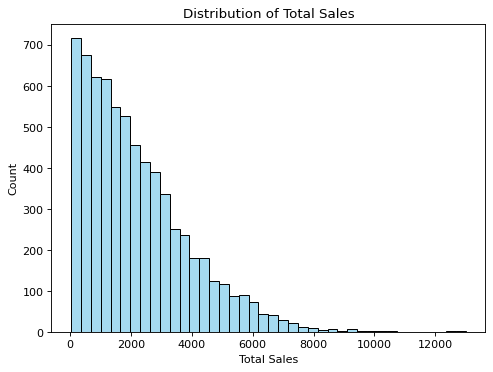

In [8]:
# distribution of the target variable -- positively skewed, as most sales data is
plt.figure(figsize=(7,5))
sns.histplot(df["total_sales"], bins=40, color="skyblue")
plt.xlabel("Total Sales")
plt.title("Distribution of Total Sales")
plt.savefig("../images/sales_distribution.png", dpi=150)
plt.show()

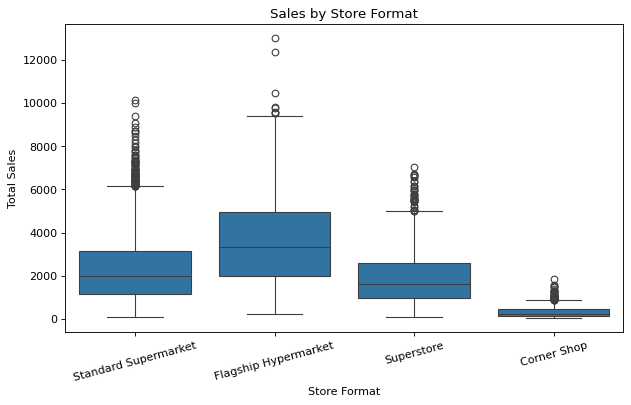

In [9]:
# store format clearly separates sales volume -- Flagship Hypermarkets/Superstores
# sell far more than Corner Shops
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="store_format", y="total_sales")
plt.xlabel("Store Format")
plt.ylabel("Total Sales")
plt.title("Sales by Store Format")
plt.xticks(rotation=15)
plt.savefig("../images/sales_by_format.png", dpi=150)
plt.show()

## how low can we actually expect to go?


In [10]:
cat_check_cols = ["store_code", "product_category", "fat_content", "store_size", "store_location_tier", "store_format"]
group_stats = df.groupby(cat_check_cols)["total_sales"].agg(["mean", "std", "count"])

print("Overall target std:", round(df["total_sales"].std(), 1))
print("Median within-group std (residual noise even with perfect grouping):", round(group_stats["std"].median(), 1))

Overall target std: 1697.9
Median within-group std (residual noise even with perfect grouping): 1401.8


# **Splitting Data into Feature Matrix and target vector**

In [11]:
# id: no predictive value. store_code: dropped so the model can't just memorize
# per-store averages -- store format/size/tier/age already describe the store.
target = "total_sales"

y = df[target]
X = df.drop(columns=[target, "id", "store_code"])

# price_per_kg: normalizes price by weight -- two products at the same price but
# very different weights aren't really "the same price point"
X["price_per_kg"] = X["product_price"] / X["product_weight_kg"]

# visibility_price: shelf space scaled by price -- captures whether expensive items
# get prioritized placement
X["visibility_price"] = X["shelf_visibility"] * X["product_price"]

X.head()

,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_age_years,store_size,store_location_tier,store_format,price_per_kg,visibility_price
0,14.252,Low Fat,0.0271,Frozen Foods,81.37,45,Large,Tier_3,Standard Supermarket,5.709374,2.205127
1,7.698,Low Fat,0.0720,Health And Hygiene,42.05,35,Small,Tier_1,Standard Supermarket,5.462458,3.027600
2,14.264,Regular,0.0421,Canned,41.35,33,Medium,Tier_1,Standard Supermarket,2.898906,1.740835
3,11.571,Regular,0.0449,Soft Drinks,174.35,47,Medium,Tier_3,Flagship Hypermarket,15.067842,7.828315
4,10.338,Regular,0.0120,Meat,203.06,28,Small,Tier_2,Standard Supermarket,19.642097,2.436720


# **Splitting into Training and Validation set**

In [12]:
# 80/20 split, fixed random_state so results are reproducible across reruns
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (5454, 11)
X_val shape: (1364, 11)


In [13]:
# wrangle the competition test set the same way, with the same engineered features,
# so all three models can score it later
test_df = wrangle("../data/test.csv")
test_df["price_per_kg"] = test_df["product_price"] / test_df["product_weight_kg"]
test_df["visibility_price"] = test_df["shelf_visibility"] * test_df["product_price"]

X_test = test_df.drop(columns=["id", "store_code"])
test_df.head()

,id,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,price_per_kg,visibility_price
0,row_00009,8.628,Low Fat,0.0167,Household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore,22.104775,3.185024
1,row_00015,6.993,Low Fat,0.0579,Health And Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket,37.333047,15.115953
2,row_00019,13.217,Low Fat,0.1262,Fruits And Vegetables,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,8.511765,14.197500
3,row_00020,14.034,Regular,0.0761,Frozen Foods,200.71,STORE-DKU,30,Unknown,Tier_2,Standard Supermarket,14.301696,15.274031
4,row_00023,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,11.527980,9.788350


In [14]:
# baseline: predict the training mean for every row -- any real model needs to
# beat this by a wide margin
y_pred_baseline = [y_train.mean()] * len(y_val)
baseline_rmse = root_mean_squared_error(y_val, y_pred_baseline)
print("Baseline RMSE:", round(baseline_rmse, 2))

Baseline RMSE: 1716.87


In [15]:
# categorical vs numeric columns, used to build the shared preprocessor below
categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols, numeric_cols

(['fat_content', 'product_category', 'store_size', 'store_location_tier', 'store_format'], ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'price_per_kg', 'visibility_price'])

In [16]:
# ONE preprocessor for all three models: all three are tree-based, so no scaling is
# needed -- one-hot encode the categoricals, pass numeric columns straight through.
# sparse_output=False because HistGradientBoostingRegressor requires dense input.
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
], remainder="passthrough")

In [17]:
def evaluate(model, X_train, y_train, X_val, y_val):
    """Fit-time evaluation: prints and returns (train_rmse, val_rmse)."""
    train_rmse = root_mean_squared_error(y_train, model.predict(X_train))
    val_rmse = root_mean_squared_error(y_val, model.predict(X_val))
    print("Training RMSE:", round(train_rmse, 2))
    print("Validation RMSE:", round(val_rmse, 2))
    return train_rmse, val_rmse


def generate_submission(preds, ids, path):
    """Write a Kaggle-format submission file: id + predicted total_sales.
    Predictions are clipped at 0 since sales can't be negative."""
    preds = np.clip(preds, 0, None)
    submission = pd.DataFrame({"id": ids, "total_sales": preds})
    submission.to_csv(path, index=False)
    return submission


# collect each model's results here for the comparison + blend at the end
val_rmses = {}
val_preds_by_model = {}
test_preds_by_model = {}

# **Model 1: Gradient Boosting**

Best single model tested — sklearn's classic (non-histogram) gradient boosting implementation.

In [18]:
model_gbr = make_pipeline(
    preprocessor,
    GradientBoostingRegressor(
        random_state=42, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8
    )
)
model_gbr.fit(X_train, y_train)

_, val_rmses["Gradient Boosting"] = evaluate(model_gbr, X_train, y_train, X_val, y_val)
val_preds_by_model["Gradient Boosting"] = model_gbr.predict(X_val)

Training RMSE: 998.48
Validation RMSE: 1081.49


In [19]:
# generate this model's own submission file
test_preds_by_model["Gradient Boosting"] = model_gbr.predict(X_test)
submission_gbr = generate_submission(
    test_preds_by_model["Gradient Boosting"], test_df["id"], "../submissions/submission_gradient_boosting.csv"
)
submission_gbr.head()

,id,total_sales
0,row_00009,2710.388936
1,row_00015,4645.980639
2,row_00019,3182.091378
3,row_00020,3131.587777
4,row_00023,2328.670719


# **Model 2: HistGradientBoosting**

sklearn's fast, histogram-based boosting -- same algorithm family as LightGBM/XGBoost.

In [20]:
model_hgb = make_pipeline(
    preprocessor,
    HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05, max_depth=4)
)
model_hgb.fit(X_train, y_train)

_, val_rmses["HistGradientBoosting"] = evaluate(model_hgb, X_train, y_train, X_val, y_val)
val_preds_by_model["HistGradientBoosting"] = model_hgb.predict(X_val)

Training RMSE: 956.42
Validation RMSE: 1093.44


In [21]:
test_preds_by_model["HistGradientBoosting"] = model_hgb.predict(X_test)
submission_hgb = generate_submission(
    test_preds_by_model["HistGradientBoosting"], test_df["id"], "../submissions/submission_histgb.csv"
)
submission_hgb.head()

,id,total_sales
0,row_00009,2724.521437
1,row_00015,4361.286784
2,row_00019,3500.523792
3,row_00020,3163.917513
4,row_00023,2559.427611


# **Model 3: Extra Trees**

Like Random Forest, but splits are chosen randomly rather than optimally -- the extra randomness sometimes reduces overfitting further.

In [22]:
model_et = make_pipeline(
    preprocessor,
    ExtraTreesRegressor(n_estimators=500, min_samples_leaf=5, random_state=42, n_jobs=-1)
)
model_et.fit(X_train, y_train)

_, val_rmses["Extra Trees"] = evaluate(model_et, X_train, y_train, X_val, y_val)
val_preds_by_model["Extra Trees"] = model_et.predict(X_val)

Training RMSE: 794.03
Validation RMSE: 1103.08


In [23]:
test_preds_by_model["Extra Trees"] = model_et.predict(X_test)
submission_et = generate_submission(
    test_preds_by_model["Extra Trees"], test_df["id"], "../submissions/submission_extra_trees.csv"
)
submission_et.head()

,id,total_sales
0,row_00009,2705.253654
1,row_00015,4793.979978
2,row_00019,3618.604635
3,row_00020,3210.341305
4,row_00023,2757.149323


# **Blended Ensemble (all 3 models)**

Solve directly for the non-negative weights that minimize validation RMSE when combining all three models' predictions -- this is the model the final submission uses.

In [24]:
model_names = list(val_preds_by_model.keys())
val_pred_matrix = np.column_stack([val_preds_by_model[name] for name in model_names])

blend_weights, _ = nnls(val_pred_matrix, y_val)

print("Blend weights:")
for name, w in zip(model_names, blend_weights):
    print(f"  {name}: {w:.3f}")

blend_val = val_pred_matrix @ blend_weights
val_rmses["Blended Ensemble"] = root_mean_squared_error(y_val, blend_val)
print("\nBlended Ensemble validation RMSE:", round(val_rmses["Blended Ensemble"], 2))

Blend weights:
  Gradient Boosting: 0.786
  HistGradientBoosting: 0.000
  Extra Trees: 0.238

Blended Ensemble validation RMSE: 1077.46


In [25]:
# apply the exact same weights to the test-set predictions for the final submission
test_pred_matrix = np.column_stack([test_preds_by_model[name] for name in model_names])
blend_test_preds = test_pred_matrix @ blend_weights

submission_blend = generate_submission(blend_test_preds, test_df["id"], "../submissions/submission_blend.csv")
submission_blend.head()

,id,total_sales
0,row_00009,2771.870544
1,row_00015,4788.626836
2,row_00019,3359.426904
3,row_00020,3222.746455
4,row_00023,2484.354171


# **Comparing Results & Final Submission**

In [26]:
result_df = pd.Series(val_rmses, name="val_rmse").sort_values()
result_df

,val_rmse
Blended Ensemble,1077.460593
Gradient Boosting,1081.494427
HistGradientBoosting,1093.442234
Extra Trees,1103.083451


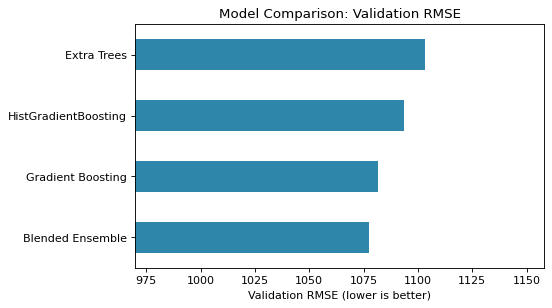

In [27]:
plt.figure(figsize=(7,4))
result_df.plot(kind="barh", color="#2E86AB")
plt.xlabel("Validation RMSE (lower is better)")
plt.title("Model Comparison: Validation RMSE")
plt.xlim(left=result_df.min() * 0.9)
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=150)
plt.show()

In [28]:
# pick whichever model had the lowest validation RMSE and use it as the final submission
best_model_name = result_df.idxmin()
print("Best model:", best_model_name)

submission_files = {
    "Gradient Boosting": "../submissions/submission_gradient_boosting.csv",
    "HistGradientBoosting": "../submissions/submission_histgb.csv",
    "Extra Trees": "../submissions/submission_extra_trees.csv",
    "Blended Ensemble": "../submissions/submission_blend.csv",
}

best_submission_path = submission_files[best_model_name]
shutil.copy(best_submission_path, "../submissions/submission_final.csv")
print("Copied", best_submission_path, "-> submissions/submission_final.csv")

Best model: Blended Ensemble
Copied ../submissions/submission_blend.csv -> submissions/submission_final.csv


In [29]:
# final sanity check before submitting to Kaggle
final = pd.read_csv("../submissions/submission_final.csv")
print(final.shape)
final.head()

(1705, 2)


,id,total_sales
0,row_00009,2771.870544
1,row_00015,4788.626836
2,row_00019,3359.426904
3,row_00020,3222.746455
4,row_00023,2484.354171
